<a href="https://colab.research.google.com/github/007-athul/DSA-case-study1/blob/main/visualization_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

(244, 8)
   total_bill   tip     sex smoker  day    time  size    tip_pct
0       16.99  1.01  Female     No  Sun  Dinner     2   5.944673
1       10.34  1.66    Male     No  Sun  Dinner     3  16.054159
2       21.01  3.50    Male     No  Sun  Dinner     3  16.658734
3       23.68  3.31    Male     No  Sun  Dinner     2  13.978041
4       24.59  3.61  Female     No  Sun  Dinner     4  14.680765
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
tip_pct       0
dtype: int64


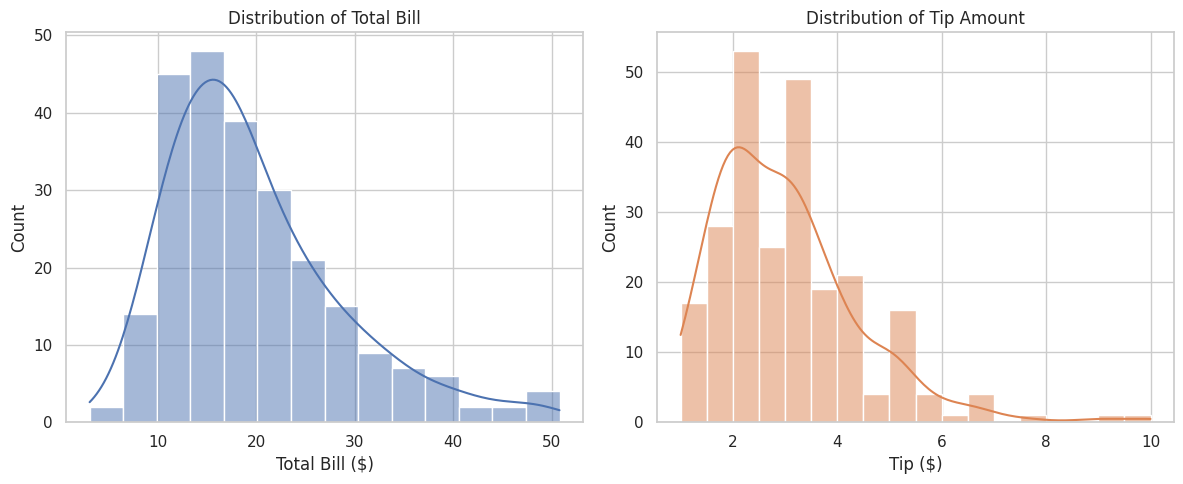

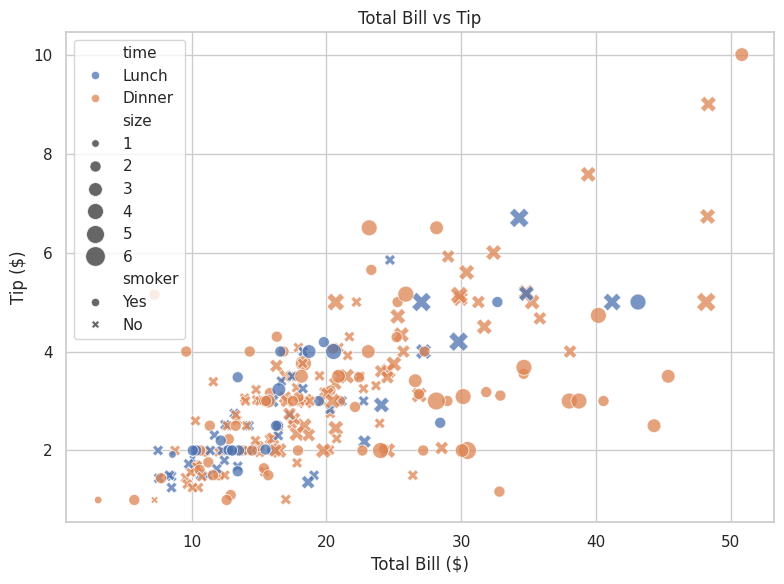

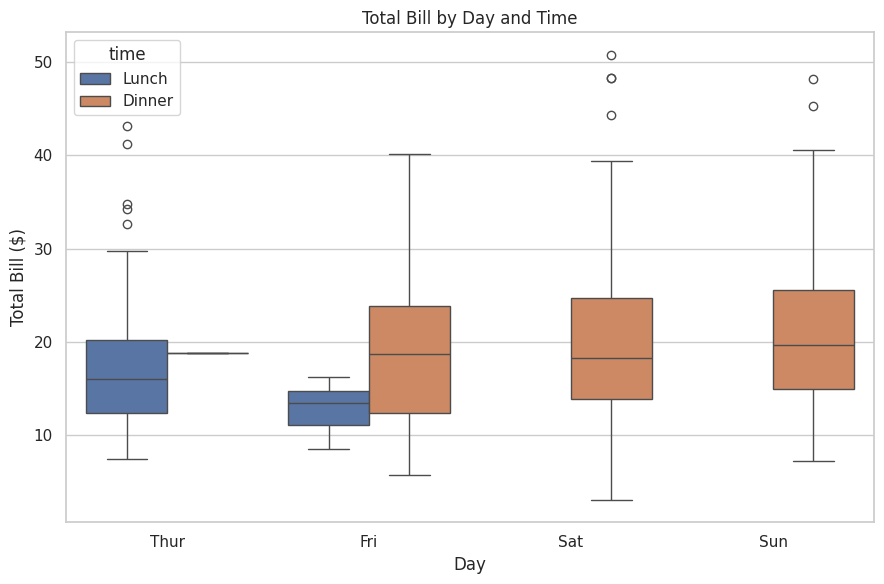

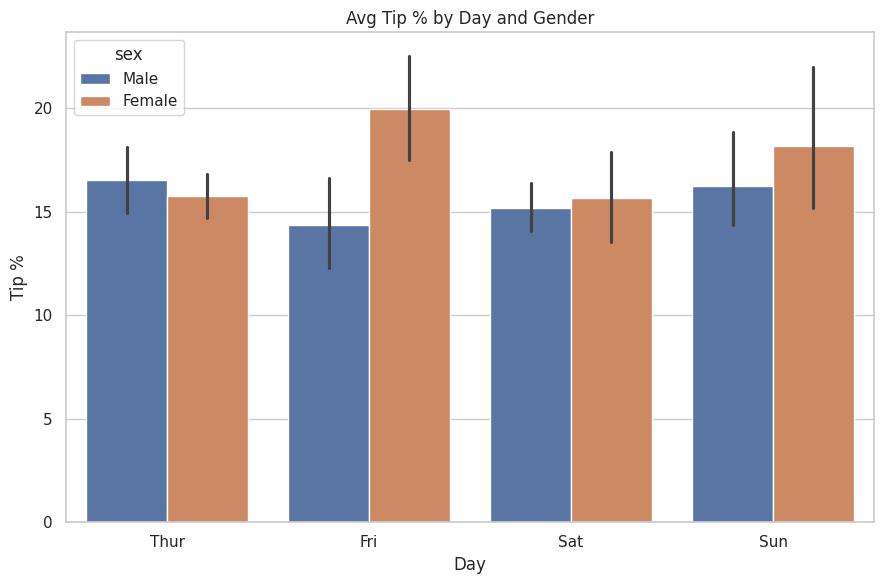

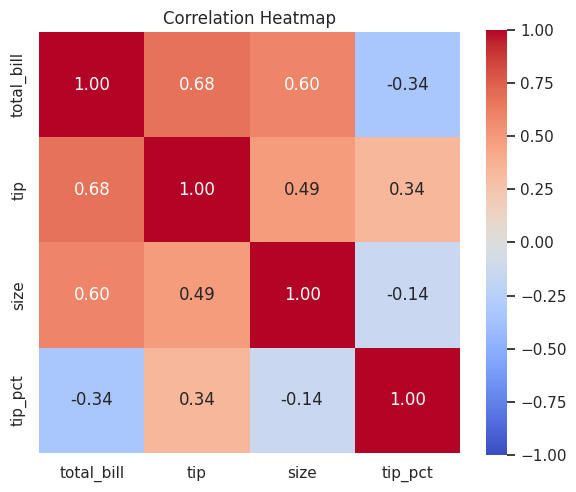

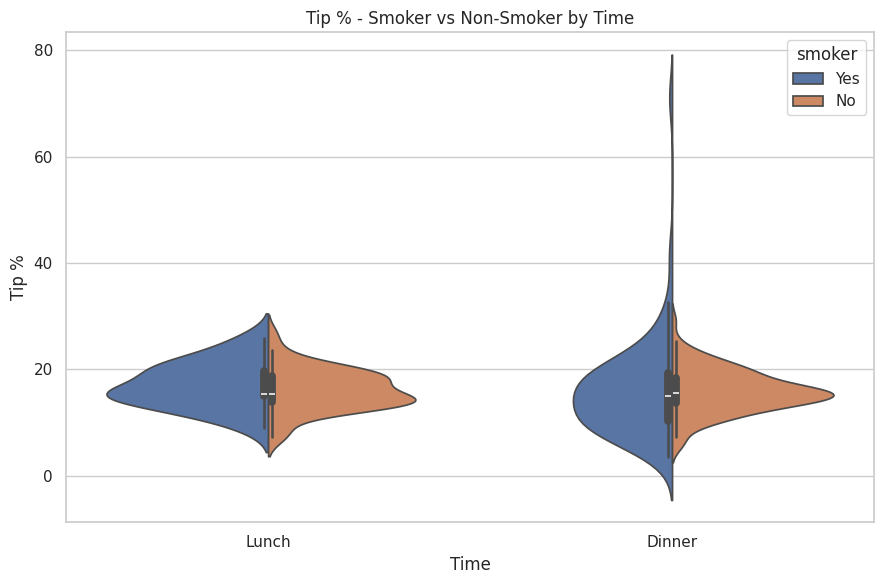

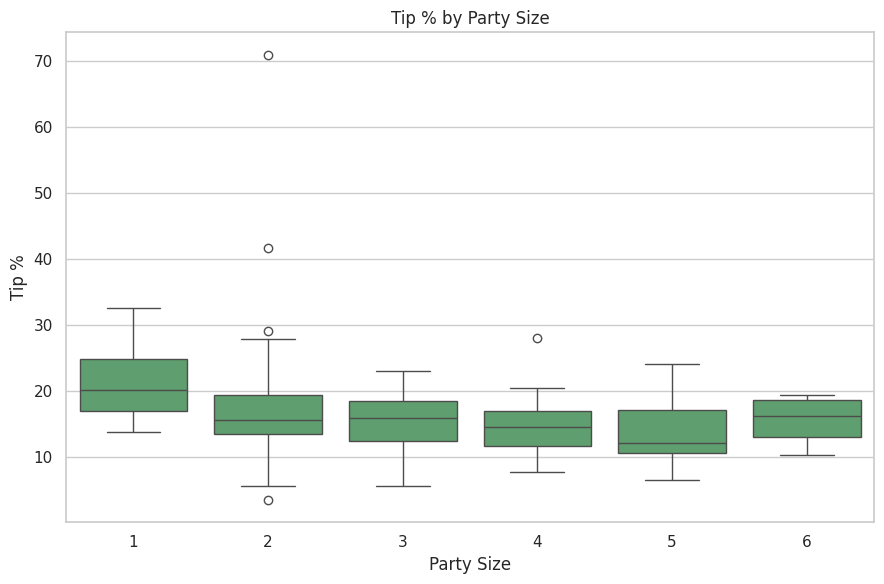

day
Thur    16.127563
Fri     16.991303
Sat     15.315172
Sun     16.689729
Name: tip_pct, dtype: float64
smoker  time  
Yes     Lunch     17.040414
        Dinner    16.082767
No      Lunch     16.092009
        Dinner    15.865277
Name: tip_pct, dtype: float64
size
1    21.729202
2    16.571919
3    15.215685
4    14.594901
5    14.149549
6    15.622920
Name: tip_pct, dtype: float64
            total_bill       tip      size   tip_pct
total_bill    1.000000  0.675734  0.598315 -0.338624
tip           0.675734  1.000000  0.489299  0.342370
size          0.598315  0.489299  1.000000 -0.142860
tip_pct      -0.338624  0.342370 -0.142860  1.000000


In [5]:


sns.set_theme(style="whitegrid", palette="deep")

df = sns.load_dataset('tips')
df['tip_pct'] = df['tip'] / df['total_bill'] * 100

print(df.shape)
print(df.head())
print(df.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['total_bill'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Total Bill')
axes[0].set_xlabel('Total Bill ($)')

sns.histplot(df['tip'], kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Distribution of Tip Amount')
axes[1].set_xlabel('Tip ($)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', style='smoker', size='size', sizes=(30, 200), alpha=0.75)
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='day', y='total_bill', hue='time')
plt.title('Total Bill by Day and Time')
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.barplot(data=df, x='day', y='tip_pct', hue='sex', errorbar=('ci', 95))
plt.title('Avg Tip % by Day and Gender')
plt.xlabel('Day')
plt.ylabel('Tip %')
plt.tight_layout()
plt.show()

num_df = df[['total_bill', 'tip', 'size', 'tip_pct']]
corr = num_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.violinplot(data=df, x='time', y='tip_pct', hue='smoker', split=True)
plt.title('Tip % - Smoker vs Non-Smoker by Time')
plt.xlabel('Time')
plt.ylabel('Tip %')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='size', y='tip_pct', color='#55A868')
plt.title('Tip % by Party Size')
plt.xlabel('Party Size')
plt.ylabel('Tip %')
plt.tight_layout()
plt.show()

print(df.groupby('day', observed=True)['tip_pct'].mean())
print(df.groupby(['smoker', 'time'], observed=True)['tip_pct'].mean())
print(df.groupby('size')['tip_pct'].mean())
print(corr)

**Insights**

*Bill & Tip amounts – Most bills are $10-20, most tips are $2-4. Nothing too extreme.
* Bill vs Tip – Bigger bill, bigger tip. Pretty obvious trend.


* Bill by Day/Time – Weekends have the biggest bills, especially dinner.  
* Tip % by Day/Gender – Stays around 15-17% no matter the day or gender.

*  Correlation Heatmap – Bigger bills mean bigger tips in $, but a smaller tip %. People don't tip proportionally more just because they spent more.
* Smokers vs Non-smokers – Smokers tip less consistently (some high, some low). Non-smokers are more predictable.

*Tip % by Group Size – Solo diners tip the most (~22%). Bigger groups tip less (~14-15%) — probably why restaurants add auto-gratuity for large tables.








